In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:

df = pd.read_csv("../data/truck_market_dataset_10000.csv")

print(df.shape)
print(df.head())
print(df.info())

(10000, 22)
   year       make            model      trim         body transmission_type  \
0  2014  Chevrolet   Impala Limited  LT Fleet        Sedan         automatic   
1  2003      Dodge  Ram Pickup 1500       SLT     Quad Cab               NaN   
2  2007    Pontiac               G6        GT  Convertible         automatic   
3  2011     Toyota          Corolla        LE        Sedan         automatic   
4  2012      Lexus           ES 350      Base        Sedan               NaN   

                 vin location  condition  mileage  ...  \
0  2g1wb5e37e1112559       fl        4.0  21507.0  ...   
1  1d7ha18n13s152972       mo       31.0  79712.0  ...   
2  1g2zh361474252178       nj       34.0  65698.0  ...   
3  jtdbu4eexb9167571       fl       43.0  23634.0  ...   
4  jthbk1eg6c2495519       pa       35.0  26483.0  ...   

                             seller      mmr    price  \
0                    gm remarketing  13450.0  13800.0   
1                  tdaf remarketing   6025.0

In [3]:
df = df[df["price"] > 1000]
df.shape

(9691, 22)

In [4]:
df = df[df["mileage"] > 100]
df.shape

(9664, 22)

In [5]:
core_cols = [
    "make",
    "model",
    "year",
    "price",
    "mileage"
]

df = df.dropna(subset=core_cols)

In [6]:
df.head()

,year,make,model,trim,body,transmission_type,vin,location,condition,mileage,...,seller,mmr,price,auction_date,source,source_type,truck_type,first_seen_date,status,last_seen_date
0,2014,Chevrolet,Impala Limited,LT Fleet,Sedan,automatic,2g1wb5e37e1112559,fl,4.0,21507.0,...,gm remarketing,13450.0,13800.0,2015-02-22 21:00:00+00:00,CommercialTruckTrader,retail,Day Cab,2014-11-11 21:00:00+00:00,ended,2015-02-22 21:00:00+00:00
1,2003,Dodge,Ram Pickup 1500,SLT,Quad Cab,NaN,1d7ha18n13s152972,mo,31.0,79712.0,...,tdaf remarketing,6025.0,6300.0,2015-01-19 18:30:00+00:00,IronPlanet,retail,Sleeper,2014-12-05 18:30:00+00:00,ended,2015-01-19 18:30:00+00:00
2,2007,Pontiac,G6,GT,Convertible,automatic,1g2zh361474252178,nj,34.0,65698.0,...,car authority inc,7375.0,8000.0,2015-01-13 17:30:00+00:00,IronPlanet,retail,Flatbed,2014-12-03 17:30:00+00:00,ended,2015-01-13 17:30:00+00:00
3,2011,Toyota,Corolla,LE,Sedan,automatic,jtdbu4eexb9167571,fl,43.0,23634.0,...,world omni financial corporation,10800.0,11400.0,2015-01-26 17:30:00+00:00,TruckPaper,retail,Reefer,2014-12-01 17:30:00+00:00,active,2015-01-26 17:30:00+00:00
4,2012,Lexus,ES 350,Base,Sedan,NaN,jthbk1eg6c2495519,pa,35.0,26483.0,...,meridian remarketing,22500.0,23300.0,2015-01-29 17:00:00+00:00,CommercialTruckTrader,retail,Reefer,2014-12-28 17:00:00+00:00,ended,2015-01-29 17:00:00+00:00


In [7]:
CURRENT_YEAR = 2026

df["age"] = CURRENT_YEAR - df["year"]

In [8]:
df["age"].describe()

count    9506.000000
mean       15.561750
std         3.562861
min        11.000000
25%        13.000000
50%        14.000000
75%        18.000000
max        35.000000
Name: age, dtype: float64

In [9]:
df["price_per_mile"] = (
    df["price"] /
    (df["mileage"]+1)
)

In [10]:
df["first_seen_date"] = pd.to_datetime(
    df["first_seen_date"]
)

df["last_seen_date"] = pd.to_datetime(
    df["last_seen_date"]
)

df["days_on_market"] = (
    df["last_seen_date"] -
    df["first_seen_date"]
).dt.days

In [11]:
df["days_on_market"].describe()

count    9506.000000
mean       63.655481
std        32.456315
min         7.000000
25%        36.000000
50%        64.000000
75%        92.000000
max       119.000000
Name: days_on_market, dtype: float64

In [12]:
df[["age","price"]].corr()

,age,price
age,1.000000,-0.559521
price,-0.559521,1.000000


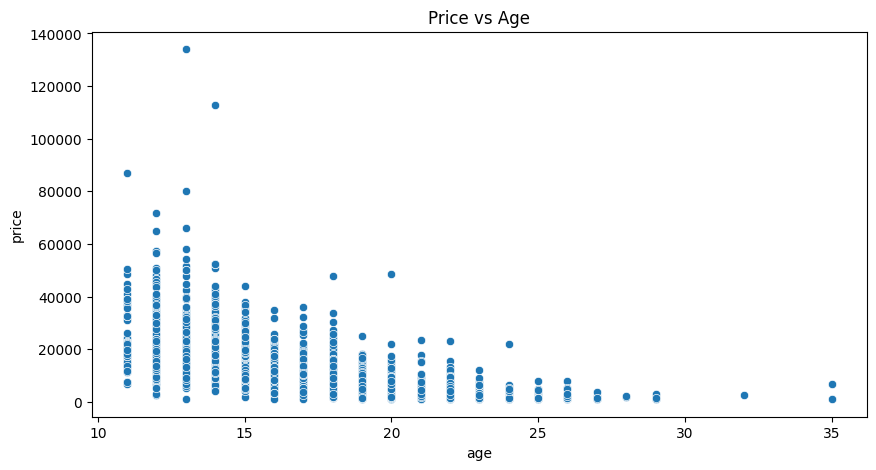

In [13]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df.sample(3000),
    x="age",
    y="price"
)

plt.title("Price vs Age")
plt.show()

In [14]:
df[["mileage","price"]].corr()

,mileage,price
mileage,1.000000,-0.579631
price,-0.579631,1.000000


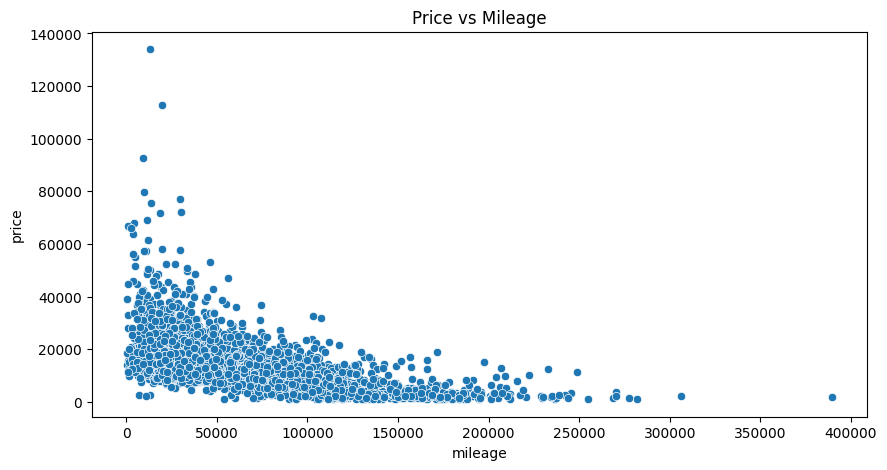

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df.sample(3000),
    x="mileage",
    y="price"
)

plt.title("Price vs Mileage")
plt.show()

In [16]:
df[["age","mileage"]].corr()

,age,mileage
age,1.000000,0.791755
mileage,0.791755,1.000000


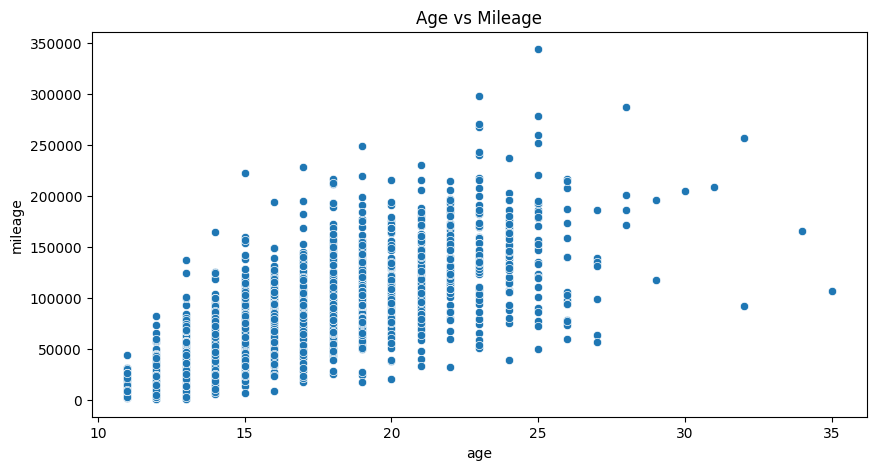

In [17]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df.sample(3000),
    x="age",
    y="mileage"
)

plt.title("Age vs Mileage")
plt.show()

In [18]:
brand_volume = (
    df["make"]
      .value_counts()
)

print(brand_volume.head(20))

make
Ford             1685
Chevrolet        1048
Nissan            896
Toyota            679
Honda             535
Dodge             520
Hyundai           387
BMW               348
Kia               333
Chrysler          301
Mercedes-Benz     294
Infiniti          256
Jeep              222
Volkswagen        215
Lexus             186
GMC               186
Mazda             166
Cadillac          121
Lincoln           110
Audi              107
Name: count, dtype: int64


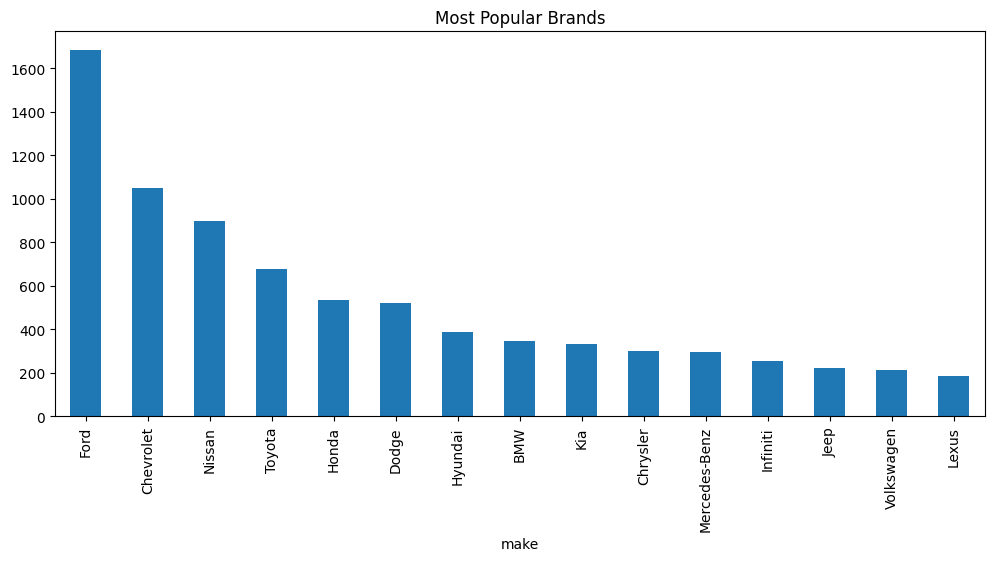

In [19]:
brand_volume.head(15).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Most Popular Brands")
plt.show()

In [20]:
model_volume = (
    df.groupby(
        ["make","model"]
    )
      .size()
      .sort_values(
          ascending=False
      )
)

print(model_volume.head(20))

make       model           
Nissan     Altima              304
Ford       F-150               274
           Fusion              250
           Escape              218
Toyota     Camry               209
Ford       Focus               201
Honda      Accord              169
BMW        3 Series            151
Honda      Civic               151
Chevrolet  Impala              143
Toyota     Corolla             141
Ford       Explorer            133
Chevrolet  Malibu              126
Infiniti   G Sedan             126
Nissan     Maxima              123
Hyundai    Elantra             122
Chrysler   Town and Country    117
Chevrolet  Cruze               117
Dodge      Grand Caravan       115
Hyundai    Sonata              114
dtype: int64


In [21]:
segment_price = (
    df.groupby(
        [
            "make",
            "model",
            "year"
        ]
    )["price"]
      .median()
      .reset_index()
)

In [22]:
print(segment_price.head(20))

     make    model  year    price
0   Acura       CL  2001   2500.0
1   Acura       CL  2003   2300.0
2   Acura      ILX  2013  20000.0
3   Acura  Integra  1996   1450.0
4   Acura      MDX  2001   2800.0
5   Acura      MDX  2002   6250.0
6   Acura      MDX  2003   2300.0
7   Acura      MDX  2004   7800.0
8   Acura      MDX  2005   5100.0
9   Acura      MDX  2006   7600.0
10  Acura      MDX  2007  12200.0
11  Acura      MDX  2009  21400.0
12  Acura      MDX  2010  21725.0
13  Acura      MDX  2011  27000.0
14  Acura      MDX  2012  30200.0
15  Acura      MDX  2013  26400.0
16  Acura      MDX  2014  36000.0
17  Acura      RDX  2007  13700.0
18  Acura      RDX  2013  26300.0
19  Acura       RL  2004   5500.0


In [23]:
df["days_on_market"].describe()

count    9506.000000
mean       63.655481
std        32.456315
min         7.000000
25%        36.000000
50%        64.000000
75%        92.000000
max       119.000000
Name: days_on_market, dtype: float64

In [24]:
dom_brand = (
    df.groupby(
        "make"
    )["days_on_market"]
      .mean()
      .sort_values()
)

print(dom_brand.head(20))

make
mazda         20.000000
Oldsmobile    36.500000
Ferrari       46.000000
mercedes      48.500000
chrysler      48.714286
Scion         50.230769
Mercury       51.700000
mercury       53.000000
hyundai       54.000000
dodge         55.000000
Saturn        55.633333
Bentley       56.000000
Jaguar        56.200000
smart         56.200000
FIAT          59.000000
Porsche       59.107143
chevrolet     60.333333
Subaru        60.604651
Infiniti      60.941406
Ram           62.154762
Name: days_on_market, dtype: float64


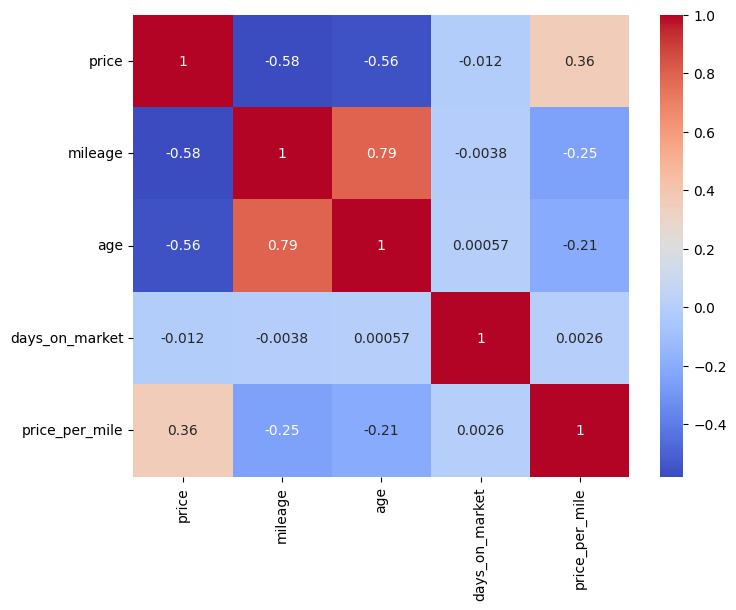

In [25]:
numeric_cols = [
    "price",
    "mileage",
    "age",
    "days_on_market",
    "price_per_mile"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [26]:
df['price'].describe()

count      9506.000000
mean      14147.375131
std        9542.052166
min        1025.000000
25%        7700.000000
50%       12600.000000
75%       18600.000000
max      134000.000000
Name: price, dtype: float64

In [27]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission_type', 'vin',
       'location', 'condition', 'mileage', 'color', 'interior', 'seller',
       'mmr', 'price', 'auction_date', 'source', 'source_type', 'truck_type',
       'first_seen_date', 'status', 'last_seen_date', 'age', 'price_per_mile',
       'days_on_market'],
      dtype='str')

In [28]:
df=df[df['age']<=26]

In [29]:
df.shape

(9451, 25)

In [30]:
model_popularity = (
    df.groupby(["make", "model"])
      .size()
      .reset_index(name="listing_count")
)

max_count = model_popularity["listing_count"].max()

model_popularity["popularity_score"] = (
    model_popularity["listing_count"] / max_count
)

In [31]:
market_velocity = (
    df.groupby(["make", "model"])["days_on_market"]
      .mean()
      .reset_index()
)

market_velocity.rename(
    columns={
        "days_on_market": "avg_days_on_market"
    },
    inplace=True
)

In [32]:
feature_columns = [
    'make',
    'model',
    'body',
    'transmission_type',
    'seller',
    'source_type',
    'truck_type',
    'status',
    'age',
    'mileage',
    'mmr',
    'days_on_market',
    'mileage_per_year'      # NEW
]

In [33]:
categorical_features = [
    "make",
    "model",
    "body",
    "transmission_type",
    "seller",
    "source_type",
    "truck_type",
    "status"
]

In [34]:
numerical_features = [
    "age",
    "mileage",
    "mmr",
    "days_on_market"
]

In [35]:
missing_pct = df[numerical_features+categorical_features].isnull().mean() * 100
print(missing_pct)

age                   0.000000
mileage               0.000000
mmr                   0.000000
days_on_market        0.000000
make                  0.000000
model                 0.000000
body                  0.507883
transmission_type    11.268649
seller                0.000000
source_type           0.000000
truck_type            0.000000
status                0.000000
dtype: float64


In [36]:
df["body"] = df["body"].fillna("Unknown")
df["transmission_type"] = df["transmission_type"].fillna("Unknown")

In [37]:
upper_limit = df["price"].quantile(0.99)

df = df[
    df["price"] <= upper_limit
]

In [38]:
df["mileage_per_year"] = (
    df["mileage"] / (df["age"] + 1)
)

In [39]:
X = df[
    categorical_features +
    numerical_features
]

y = df["price"]

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
feature_lookup = (
    df.groupby(["make", "model"])
      .agg({

          "body":
              lambda x: x.mode().iloc[0],

          "transmission_type":
              lambda x: x.mode().iloc[0],

          "seller":
              lambda x: x.mode().iloc[0],

          "source_type":
              lambda x: x.mode().iloc[0],

          "truck_type":
              lambda x: x.mode().iloc[0],

          "status":
              lambda x: x.mode().iloc[0],

          "mmr":
              "median",

          "days_on_market":
              "median",

          "mileage_per_year":
              "median"      # NEW

      })
      .reset_index()
)

In [42]:
from catboost import CatBoostRegressor

price_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100
)

price_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

0:	learn: 7940.9567032	total: 69.9ms	remaining: 1m 9s
100:	learn: 1637.5414964	total: 592ms	remaining: 5.26s
200:	learn: 1529.3589069	total: 1.21s	remaining: 4.81s
300:	learn: 1466.2108925	total: 1.83s	remaining: 4.26s
400:	learn: 1411.4612864	total: 2.46s	remaining: 3.67s
500:	learn: 1356.8010963	total: 3.09s	remaining: 3.08s
600:	learn: 1301.4215119	total: 3.75s	remaining: 2.49s
700:	learn: 1253.3737831	total: 4.39s	remaining: 1.87s
800:	learn: 1210.5372302	total: 5.05s	remaining: 1.25s
900:	learn: 1171.2881742	total: 5.73s	remaining: 629ms
999:	learn: 1128.5215205	total: 6.36s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [43]:
pred = price_model.predict(X_test)

In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 1024.4931131036053
R2: 0.9689237021354763


In [45]:
errors = y_test - pred

print(errors.describe())

count     1872.000000
mean         7.935593
std       1471.140402
min     -11445.264549
25%       -692.959272
50%         27.067093
75%        787.659243
max       9491.893954
Name: price, dtype: float64


In [46]:



class VehicleRecommendationEngine:

    def __init__(self,
                 price_model,
                 shap_explainer,
                 feature_lookup,
                 model_popularity):

        self.price_model = price_model
        self.shap_explainer = shap_explainer
        self.feature_lookup = feature_lookup
        self.model_popularity = model_popularity

    # ---------------------------------------------------
    # STEP 1 : Predict fair market price
    # ---------------------------------------------------
    def predict_price(self, make, model, age, mileage):

        row = self.feature_lookup[
            (self.feature_lookup["make"] == make) &
            (self.feature_lookup["model"] == model)
        ]

        if len(row) == 0:
            row = pd.DataFrame([{
                "body": "Sedan",
                "transmission_type": "Automatic",
                "seller": "Dealer",
                "source_type": "retail",
                "truck_type": "Standard",
                "status": "active",
                "mmr": self.feature_lookup["mmr"].median(),
                "days_on_market": self.feature_lookup["days_on_market"].median()
            }])

        mileage_per_year = mileage / (age + 1)

        input_df = pd.DataFrame([{
            "make": make,
            "model": model,
            "body": row["body"].values[0],
            "transmission_type": row["transmission_type"].values[0],
            "seller": row["seller"].values[0],
            "source_type": row["source_type"].values[0],
            "truck_type": row["truck_type"].values[0],
            "status": row["status"].values[0],
            "age": age,
            "mileage": mileage,
            "mmr": row["mmr"].values[0],
            "days_on_market": row["days_on_market"].values[0],
            "mileage_per_year": mileage_per_year
        }])

        predicted_price = self.price_model.predict(input_df)[0]

        return predicted_price, input_df

    # ---------------------------------------------------
    # STEP 2 : SHAP explanation (SAFE FIXED)
    # ---------------------------------------------------
    def explain_price(self, input_df):

        shap_values = self.shap_explainer.shap_values(input_df)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_values = np.array(shap_values)

        if shap_values.ndim == 3:
            shap_values = shap_values[0][0]
        elif shap_values.ndim == 2:
            shap_values = shap_values[0]

        shap_values = shap_values.flatten()

        features = list(input_df.columns)

        min_len = min(len(features), len(shap_values))

        df = pd.DataFrame({
            "feature": features[:min_len],
            "impact": shap_values[:min_len]
        })

        df["abs_impact"] = df["impact"].abs()

        return df.sort_values("abs_impact", ascending=False).drop(columns=["abs_impact"])

    # ---------------------------------------------------
    # STEP 3 : Market popularity score
    # ---------------------------------------------------
    def popularity_score(self, make, model):

        row = self.model_popularity[
            (self.model_popularity["make"] == make) &
            (self.model_popularity["model"] == model)
        ]

        if len(row) == 0:
            return 0.50

        return row["popularity_score"].values[0]

    # ---------------------------------------------------
    # STEP 4 : Mileage health score
    # ---------------------------------------------------
    def mileage_health_score(self, age, mileage):

        expected = max(age * 12000, 1)
        ratio = mileage / expected

        if ratio <= 0.80:
            return 1.0
        elif ratio <= 1.00:
            return 0.80
        elif ratio <= 1.20:
            return 0.60
        elif ratio <= 1.40:
            return 0.30
        else:
            return 0.10

    # ---------------------------------------------------
    # STEP 5 : EXPLAINABLE AI (ONE STABLE COLUMN)
    # ---------------------------------------------------
    def shap_explainer_human(self, shap_df, recommendation):

        if shap_df is None or len(shap_df) == 0:
            return "The model estimated price based on vehicle characteristics and market trends."

        df = shap_df.copy()

        # keep only meaningful signals
        df = df.sort_values("impact", key=abs, ascending=False)

        positive = []
        negative = []

        for _, r in df.iterrows():

            feature = r["feature"]
            impact = r["impact"]

            # ignore weak or noisy features
            if feature in ["body", "seller", "truck_type", "status", "source_type"]:
                continue

            if abs(impact) < 0.01:
                continue

            if impact > 0:
                positive.append(feature)
            else:
                negative.append(feature)

            if len(positive) + len(negative) >= 5:
                break

        # -------------------------------
        # BUILD HUMAN SENTENCE
        # -------------------------------

        explanation = []

        if negative:
            explanation.append(
                f"Price is mainly reduced by {', '.join(negative[:2])}"
            )

        if positive:
            explanation.append(
                f"Price is increased by {', '.join(positive[:2])}"
            )

        if len(explanation) == 0:
            return "Price is determined by combined vehicle condition and market signals."

        return " while ".join(explanation)


    def build_human_reason(self, raw_gap, mileage_score, popularity, recommendation):
    
        reason = []

        # ---------------- PRICE VIEW ----------------
        if raw_gap > 0.20:
            reason.append("This car is priced below market value, making it a good deal")
        elif raw_gap < -0.10:
            reason.append("This car is priced above market value, indicating overpricing")
        else:
            reason.append("This car is fairly priced based on market comparison")

        # ---------------- CONDITION VIEW ----------------
        if mileage_score > 0.80:
            reason.append("It has low mileage for its age, which is a positive sign")
        elif mileage_score < 0.30:
            reason.append("It has high mileage for its age, which is a concern")

        # ---------------- MARKET VIEW ----------------
        if popularity > 0.60:
            reason.append("This model is in strong market demand")
        elif popularity < 0.40:
            reason.append("This model has weak market demand")

        # ---------------- DECISION CONTEXT ----------------
        if recommendation in ["STRONG BUY", "BUY"]:
            reason.append("Overall conditions suggest it is a good buying opportunity")
        elif recommendation in ["AVOID", "WEAK AVOID"]:
            reason.append("Overall signals suggest avoiding this purchase")

        return " ".join(reason)

    # ---------------------------------------------------
    # STEP 6 : FINAL RECOMMENDATION ENGINE
    # ---------------------------------------------------
    def recommend(self, make, model, age, mileage, listing_price):

        predicted_price, input_df = self.predict_price(
            make, model, age, mileage
        )

        shap_df = self.explain_price(input_df)

        popularity = self.popularity_score(make, model)
        mileage_score = self.mileage_health_score(age, mileage)

        raw_gap = (predicted_price - listing_price) / predicted_price
        discount_score = np.tanh(2 * raw_gap)

        final_score = (
            0.70 * discount_score +
            0.20 * mileage_score +
            0.10 * popularity
        )

        if final_score >= 0.70:
            recommendation = "STRONG BUY"
        elif final_score >= 0.55:
            recommendation = "BUY"
        elif final_score >= 0.40:
            recommendation = "HOLD"
        elif final_score >= 0.25:
            recommendation = "WEAK AVOID"
        else:
            recommendation = "AVOID"

        # ✅ SINGLE EXPLANATION COLUMN (FIX)
        ai_reason = self.shap_explainer_human(shap_df, recommendation)
        reason = self.build_human_reason(
            raw_gap,
            mileage_score,
            popularity,
            recommendation
        )
        


        return {
            "make": make,
            "model": model,
            "recommendation": recommendation,
            "predicted_market_price": round(predicted_price, 2),
            "listing_price": listing_price,
            "score": round(final_score, 3),
            "reason": reason
        }

In [47]:
import shap

explainer = shap.TreeExplainer(
    price_model
)

engine = VehicleRecommendationEngine(

    price_model=price_model,

    shap_explainer=explainer,

    feature_lookup=feature_lookup,

    model_popularity=model_popularity
)

/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [48]:
print(dir(engine))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'build_human_reason', 'explain_price', 'feature_lookup', 'mileage_health_score', 'model_popularity', 'popularity_score', 'predict_price', 'price_model', 'recommend', 'shap_explainer', 'shap_explainer_human']


In [49]:
test_cases = pd.DataFrame([

    # ================= BUY CASES =================

    {
        "make": "Ford",
        "model": "F-150",
        "age": 3,
        "mileage": 28000,
        "listing_price": 11000
    },

    {
        "make": "Toyota",
        "model": "Camry",
        "age": 4,
        "mileage": 35000,
        "listing_price": 9000
    },

    {
        "make": "Honda",
        "model": "Accord",
        "age": 5,
        "mileage": 42000,
        "listing_price": 8500
    },

    {
        "make": "Nissan",
        "model": "Altima",
        "age": 2,
        "mileage": 18000,
        "listing_price": 10000
    },


    # ================= AVOID CASES =================

    {
        "make": "BMW",
        "model": "3 Series",
        "age": 9,
        "mileage": 165000,
        "listing_price": 24000
    },

    {
        "make": "Ford",
        "model": "F-150",
        "age": 10,
        "mileage": 190000,
        "listing_price": 23000
    },

    {
        "make": "Toyota",
        "model": "Corolla",
        "age": 8,
        "mileage": 155000,
        "listing_price": 18000
    },

    {
        "make": "Chevrolet",
        "model": "Impala",
        "age": 7,
        "mileage": 140000,
        "listing_price": 19500
    },


    # ================= BORDERLINE =================

    {
        "make": "Ford",
        "model": "Fusion",
        "age": 5,
        "mileage": 70000,
        "listing_price": 12500
    },

    {
        "make": "Toyota",
        "model": "Corolla",
        "age": 6,
        "mileage": 75000,
        "listing_price": 11500
    },

    {
        "make": "Honda",
        "model": "Civic",
        "age": 4,
        "mileage": 60000,
        "listing_price": 13500
    },

    {
        "make": "Hyundai",
        "model": "Elantra",
        "age": 3,
        "mileage": 50000,
        "listing_price": 14000
    }

])

In [ ]:
results = []

for _, row in test_cases.iterrows():

    result = engine.recommend(
        make=row["make"],
        model=row["model"],
        age=row["age"],
        mileage=row["mileage"],
        listing_price=row["listing_price"]
    )

    results.append({

        "make": row["make"],
        "model": row["model"],
        "age": row["age"],
        "mileage": row["mileage"],
        "listing_price": row["listing_price"],

        "recommendation": result["recommendation"],
        "predicted_price": result["predicted_market_price"],
        "score": result["score"],

        # ✅ THIS IS THE FIX
        "reason": result["reason"]
    })

results_df = pd.DataFrame(results)


This car is priced below market value, making it a good deal It has low mileage for its age, which is a positive sign This model is in strong market demand Overall conditions suggest it is a good buying opportunity


In [54]:
from IPython.display import display
display(results_df)

,make,model,age,mileage,listing_price,recommendation,predicted_price,score,reason
0,Ford,F-150,3,28000,11000,STRONG BUY,20992.40,0.808,"This car is priced below market value, making it a good deal It has low mileage for its age, which is a positive sign This model is in strong market demand Overall conditions suggest it is a good buying opportunity"
1,Toyota,Camry,4,35000,9000,BUY,13699.41,0.684,"This car is priced below market value, making it a good deal It has low mileage for its age, which is a positive sign This model is in strong market demand Overall conditions suggest it is a good buying opportunity"
2,Honda,Accord,5,42000,8500,HOLD,10697.54,0.526,"This car is priced below market value, making it a good deal It has low mileage for its age, which is a positive sign"
3,Nissan,Altima,2,18000,10000,BUY,12764.49,0.586,"This car is priced below market value, making it a good deal It has low mileage for its age, which is a positive sign This model is in strong market demand Overall conditions suggest it is a good buying opportunity"
4,BMW,3 Series,9,165000,24000,AVOID,17227.21,-0.391,"This car is priced above market value, indicating overpricing It has high mileage for its age, which is a concern Overall signals suggest avoiding this purchase"
5,Ford,F-150,10,190000,23000,AVOID,18692.43,-0.192,"This car is priced above market value, indicating overpricing It has high mileage for its age, which is a concern This model is in strong market demand Overall signals suggest avoiding this purchase"
6,Toyota,Corolla,8,155000,18000,AVOID,9939.92,-0.581,"This car is priced above market value, indicating overpricing It has high mileage for its age, which is a concern Overall signals suggest avoiding this purchase"
7,Chevrolet,Impala,7,140000,19500,AVOID,8270.10,-0.627,"This car is priced above market value, indicating overpricing It has high mileage for its age, which is a concern Overall signals suggest avoiding this purchase"
8,Ford,Fusion,5,70000,12500,WEAK AVOID,13267.79,0.283,This car is fairly priced based on market comparison This model is in strong market demand Overall signals suggest avoiding this purchase
9,Toyota,Corolla,6,75000,11500,AVOID,10806.38,0.077,This car is fairly priced based on market comparison Overall signals suggest avoiding this purchase


In [55]:
import pickle

In [56]:
with open("vehicle_recommendation_engine.pkl", "wb") as f:
    pickle.dump(engine, f)